## PROJECT 3: Optimizers Comparison
### Techniques: SGD, Adam, RMSprop, Adagrad

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Loading MNIST dataset...


In [3]:
# Normalize
x_train = x_train.reshape(-1, 784).astype('float32') / 255
x_test = x_test.reshape(-1, 784).astype('float32') / 255

In [4]:
# Define optimizers
optimizers_list = {
    'SGD': keras.optimizers.SGD(learning_rate=0.01),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adagrad': keras.optimizers.Adagrad(learning_rate=0.01)
}

In [5]:
print("\nTraining models with different optimizers...")
histories = {}


Training models with different optimizers...


In [8]:
for name, optimizer in optimizers_list.items():
    print(f"\nTraining with {name}...")
    
    # Build model
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    history = model.fit(
        x_train[:5000], y_train[:5000],
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    
    histories[name] = history
    final_acc = history.history['val_accuracy'][-1]
    print(f"{name}: Final Validation Accuracy = {final_acc:.4f}")



Training with SGD...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD: Final Validation Accuracy = 0.8610

Training with Adam...
Adam: Final Validation Accuracy = 0.9360

Training with RMSprop...
RMSprop: Final Validation Accuracy = 0.9300

Training with Adagrad...
Adagrad: Final Validation Accuracy = 0.8950


In [9]:
# Plot comparison
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

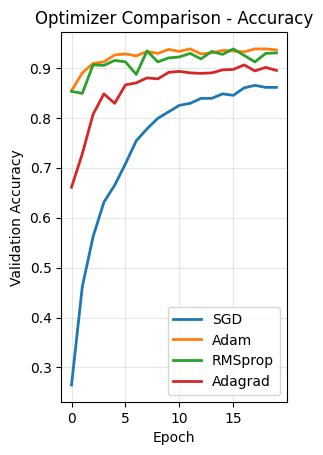

In [14]:
# Validation Accuracy
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

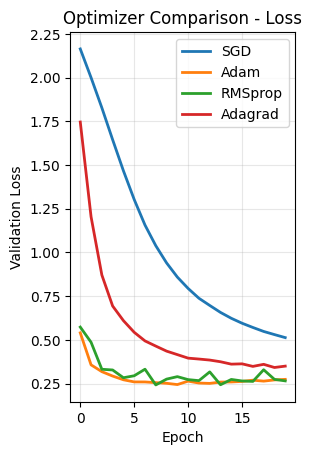

In [13]:
# Validation Loss
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Optimizer Comparison - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

In [15]:
plt.tight_layout()
plt.savefig('optimizer_comparison.png')
print("\nPlot saved as 'optimizer_comparison.png'")


Plot saved as 'optimizer_comparison.png'


<Figure size 640x480 with 0 Axes>

In [16]:
print("\n" + "="*50)
print("OPTIMIZER CHARACTERISTICS:")
print("="*50)
print("SGD: Simple but can be slow, needs learning rate tuning")
print("Adam: Adaptive learning rate, works well in most cases")
print("RMSprop: Good for RNNs, adapts learning rate")
print("Adagrad: Adapts learning rate per parameter")
print("\n✓ Adam is generally the best default choice")


OPTIMIZER CHARACTERISTICS:
SGD: Simple but can be slow, needs learning rate tuning
Adam: Adaptive learning rate, works well in most cases
RMSprop: Good for RNNs, adapts learning rate
Adagrad: Adapts learning rate per parameter

✓ Adam is generally the best default choice
